In [1]:
# ✅ Vérification de l'environnement
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Toutes les bibliothèques sont importées avec succès !")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"sklearn    : OK")

✅ Toutes les bibliothèques sont importées avec succès !
pandas     : 2.2.2
numpy      : 2.0.2
sklearn    : OK


## Les données

In [18]:
# 📥 Chargement du dataset Telco Churn
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(f"✅ Dataset chargé !")
print(f"📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Aperçu des premières lignes :")
df.head()

✅ Dataset chargé !
📐 Dimensions : 7043 lignes × 21 colonnes

📋 Aperçu des premières lignes :


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA

## Phase 1 : Vue générale du dataset

In [16]:
# ================================
# PHASE 1 — Vue générale
# ================================

print("=" * 50)
print("📊 INFORMATIONS GÉNÉRALES")
print("=" * 50)

print(f"\n📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

print("\n📋 Types de colonnes :")
print(df.dtypes)

print("\n❓ Valeurs manquantes par colonne :")
print(df.isnull().sum())

print("\n📈 Statistiques descriptives :")
df.describe()

📊 INFORMATIONS GÉNÉRALES

📐 Dimensions : 7043 lignes × 27 colonnes

📋 Types de colonnes :
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                        

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,0.343746,0.439585,0.216669,0.550192,0.209144,0.240664,0.219225,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,0.474991,0.496372,0.412004,0.497510,0.406726,0.427517,0.413751,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Analyser notre cible

📊 Distribution du Churn :
  Non (reste)  : 5174  clients (73.5%)
  Oui (quitte) : 1869 clients (26.5%)


/tmp/ipykernel_448/147933708.py:38: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/147933708.py:39: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


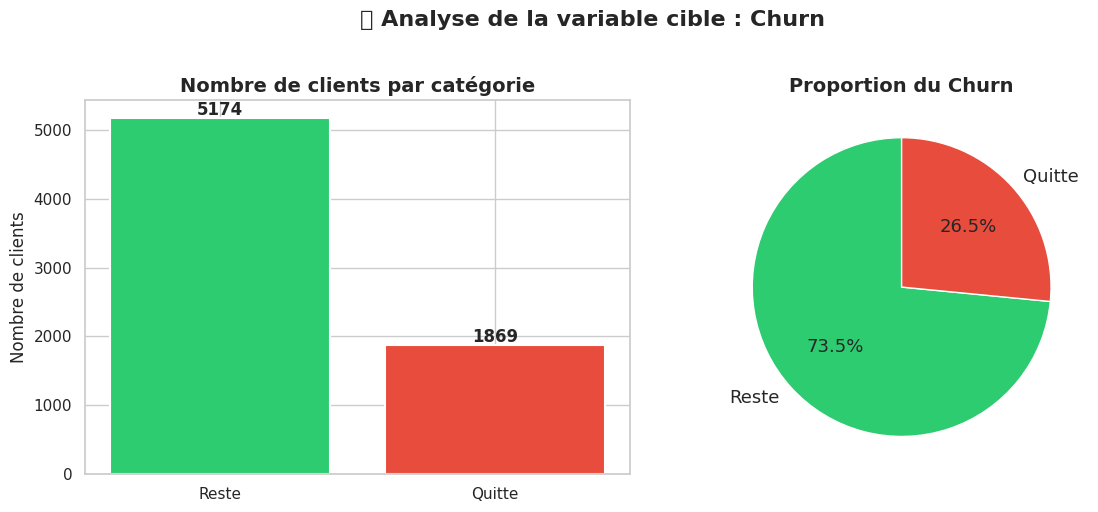


💡 OBSERVATION : Le dataset est déséquilibré — on en tiendra compte !


In [19]:
# ================================
# PHASE 2 — Distribution du Churn
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

# Style général
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Compter les churns
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("📊 Distribution du Churn :")
print(f"  Non (reste)  : {churn_counts['No']}  clients ({churn_pct['No']:.1f}%)")
print(f"  Oui (quitte) : {churn_counts['Yes']} clients ({churn_pct['Yes']:.1f}%)")

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Reste', 'Quitte'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Nombre de clients par catégorie', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Reste', 'Quitte'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Proportion du Churn', fontsize=14, fontweight='bold')

plt.suptitle('🔍 Analyse de la variable cible : Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVATION : Le dataset est déséquilibré — on en tiendra compte !")

## Les variables numériques clés

/tmp/ipykernel_448/1100470728.py:25: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/1100470728.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('numeric_features.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


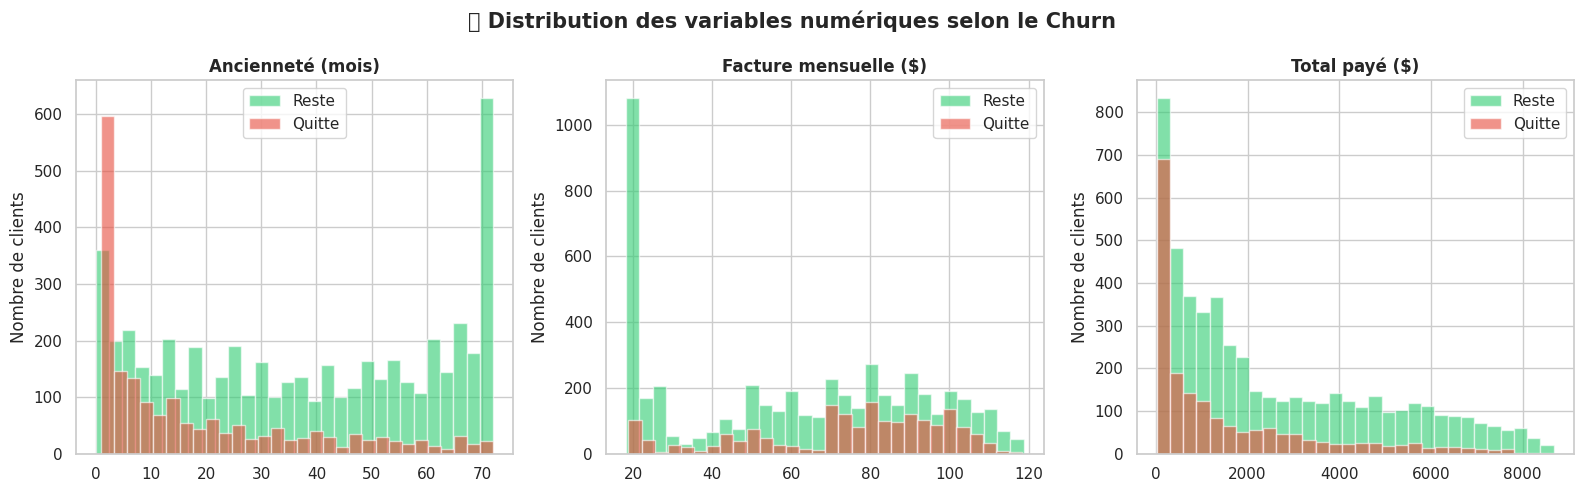

In [20]:
# ================================
# PHASE 3 — Variables numériques
# ================================

# ⚠️ Correction importante : TotalCharges est mal typée
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
titles = ['Ancienneté (mois)', 'Facture mensuelle ($)', 'Total payé ($)']
colors = ['#3498db', '#9b59b6', '#e67e22']

for i, (col, title, color) in enumerate(zip(num_cols, titles, colors)):
    axes[i].hist(df[df['Churn'] == 'No'][col].dropna(),
                 alpha=0.6, color='#2ecc71', label='Reste', bins=30)
    axes[i].hist(df[df['Churn'] == 'Yes'][col].dropna(),
                 alpha=0.6, color='#e74c3c', label='Quitte', bins=30)
    axes[i].set_title(title, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Nombre de clients')

plt.suptitle('📊 Distribution des variables numériques selon le Churn',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()

###Variables catégorielles

/tmp/ipykernel_448/1249411144.py:31: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/1249411144.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


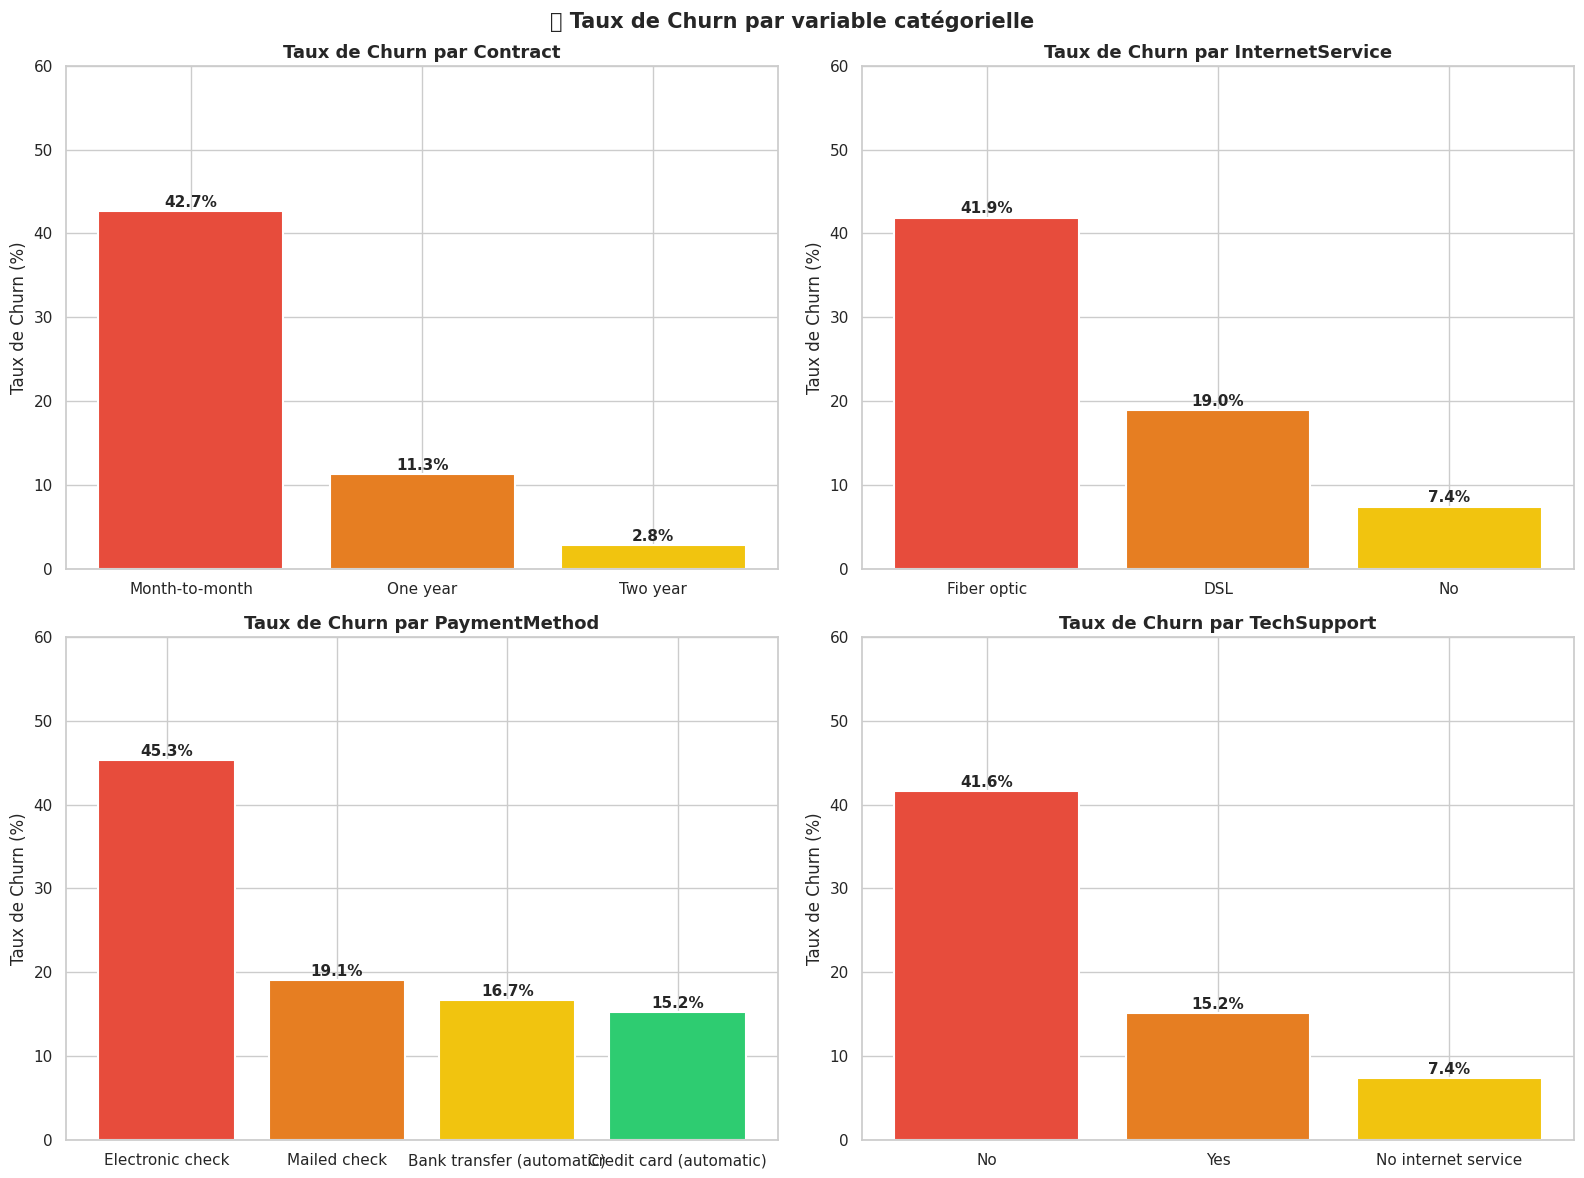

In [23]:
# ================================
# PHASE 4 — Variables catégorielles
# ================================

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],
                       color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'][:len(churn_rate)],
                       edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Taux de Churn par {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Taux de Churn (%)')
    axes[i].set_ylim(0, 60)

    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('📊 Taux de Churn par variable catégorielle',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## Etape 3 : Néttoyage des données

## Repartir proprement

In [2]:
# ================================
# RECHARGEMENT — Repartir propre
# ================================

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(f"✅ Dataset rechargé : {df.shape}")

✅ Dataset rechargé : (7043, 21)


In [3]:
# ================================
# NETTOYAGE COMPLET — VERSION FINALE
# ================================

# --- 1. Supprimer customerID ---
df = df.drop(columns=['customerID'])

# --- 2. Corriger TotalCharges ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# --- 3. Remplir les valeurs manquantes par la médiane ---
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# --- 4. Encoder la cible Churn : Yes→1, No→0 ---
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# --- 5. Encoder les colonnes VRAIMENT binaires (2 valeurs uniques) ---
# On vérifie d'abord quelles colonnes ont exactement 2 valeurs
cols_binaires = []
cols_multi = []

for col in df.select_dtypes(include='object').columns:
    n_valeurs = df[col].nunique()
    valeurs = df[col].unique().tolist()
    if n_valeurs == 2:
        cols_binaires.append(col)
    else:
        cols_multi.append(col)

print("Colonnes binaires (Label Encoding) :")
for col in cols_binaires:
    print(f"  {col} : {df[col].unique().tolist()}")

print("\nColonnes multi-valeurs (One-Hot Encoding) :")
for col in cols_multi:
    print(f"  {col} : {df[col].unique().tolist()}")

Colonnes binaires (Label Encoding) :
  gender : ['Female', 'Male']
  Partner : ['Yes', 'No']
  Dependents : ['No', 'Yes']
  PhoneService : ['No', 'Yes']
  PaperlessBilling : ['Yes', 'No']

Colonnes multi-valeurs (One-Hot Encoding) :
  MultipleLines : ['No phone service', 'No', 'Yes']
  InternetService : ['DSL', 'Fiber optic', 'No']
  OnlineSecurity : ['No', 'Yes', 'No internet service']
  OnlineBackup : ['Yes', 'No', 'No internet service']
  DeviceProtection : ['No', 'Yes', 'No internet service']
  TechSupport : ['No', 'Yes', 'No internet service']
  StreamingTV : ['No', 'Yes', 'No internet service']
  StreamingMovies : ['No', 'Yes', 'No internet service']
  Contract : ['Month-to-month', 'One year', 'Two year']
  PaymentMethod : ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [4]:
# ================================
# ENCODAGE FINAL COMPLET
# ================================

from sklearn.preprocessing import LabelEncoder

# --- 6. Simplifier les valeurs redondantes ---
# "No internet service" et "No phone service" → "No"
cols_a_simplifier = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies']

for col in cols_a_simplifier:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service'   : 'No'
    })

print("✅ Valeurs simplifiées")
print(f"   Exemple OnlineSecurity : {df['OnlineSecurity'].unique()}")

# --- 7. Label Encoding sur les colonnes binaires ---
le = LabelEncoder()

for col in cols_binaires:
    df[col] = le.fit_transform(df[col])

print(f"\n✅ Label Encoding appliqué sur {len(cols_binaires)} colonnes")

# --- 8. Après simplification, re-détecter les colonnes multi ---
# (certaines sont devenues binaires après le remplacement)
cols_maintenant_binaires = []
cols_encore_multi = []

for col in cols_a_simplifier + ['InternetService', 'Contract', 'PaymentMethod']:
    if df[col].nunique() == 2:
        cols_maintenant_binaires.append(col)
    else:
        cols_encore_multi.append(col)

print(f"\n💡 Après simplification :")
print(f"   Devenues binaires  : {cols_maintenant_binaires}")
print(f"   Encore multi       : {cols_encore_multi}")

# Label Encoding sur celles devenues binaires
for col in cols_maintenant_binaires:
    df[col] = le.fit_transform(df[col])

print(f"\n✅ Label Encoding appliqué sur les nouvelles binaires")

# --- 9. One-Hot Encoding sur les vraies multi-valeurs ---
df = pd.get_dummies(df, columns=cols_encore_multi, drop_first=False)

# Convertir les booléens True/False en 1/0
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

print(f"\n✅ One-Hot Encoding appliqué sur : {cols_encore_multi}")

✅ Valeurs simplifiées
   Exemple OnlineSecurity : ['No' 'Yes']

✅ Label Encoding appliqué sur 5 colonnes

💡 Après simplification :
   Devenues binaires  : ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
   Encore multi       : ['InternetService', 'Contract', 'PaymentMethod']

✅ Label Encoding appliqué sur les nouvelles binaires

✅ One-Hot Encoding appliqué sur : ['InternetService', 'Contract', 'PaymentMethod']


In [5]:
# ================================
# VÉRIFICATION FINALE
# ================================

print("=" * 50)
print("✅ RAPPORT DE NETTOYAGE FINAL")
print("=" * 50)

print(f"\n📐 Dimensions finales    : {df.shape}")
print(f"❓ Valeurs manquantes    : {df.isnull().sum().sum()}")
print(f"📝 Colonnes texte        : {df.select_dtypes(include='object').shape[1]}")
print(f"🔢 Colonnes numériques   : {df.select_dtypes(include=['number']).shape[1]}")

print("\n📋 Liste complète des colonnes :")
for i, col in enumerate(df.columns.tolist()):
    print(f"   {i+1:2}. {col}")

print("\n📊 Aperçu final :")
df.head(3)

✅ RAPPORT DE NETTOYAGE FINAL

📐 Dimensions finales    : (7043, 27)
❓ Valeurs manquantes    : 0
📝 Colonnes texte        : 0
🔢 Colonnes numériques   : 27

📋 Liste complète des colonnes :
    1. gender
    2. SeniorCitizen
    3. Partner
    4. Dependents
    5. tenure
    6. PhoneService
    7. MultipleLines
    8. OnlineSecurity
    9. OnlineBackup
   10. DeviceProtection
   11. TechSupport
   12. StreamingTV
   13. StreamingMovies
   14. PaperlessBilling
   15. MonthlyCharges
   16. TotalCharges
   17. Churn
   18. InternetService_DSL
   19. InternetService_Fiber optic
   20. InternetService_No
   21. Contract_Month-to-month
   22. Contract_One year
   23. Contract_Two year
   24. PaymentMethod_Bank transfer (automatic)
   25. PaymentMethod_Credit card (automatic)
   26. PaymentMethod_Electronic check
   27. PaymentMethod_Mailed check

📊 Aperçu final :


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1


##Entrainer le modèle

####1. Séparer X et Y

In [6]:
# ================================
# MODÈLE — Étape 1
# Séparer les features de la cible
# ================================

# X = les variables d'entrée (ce qu'on donne au modèle)
# y = la variable cible (ce qu'on veut prédire)

X = df.drop(columns=['Churn'])   # tout SAUF Churn
y = df['Churn']                  # uniquement Churn

print(f"✅ X (features) : {X.shape}  → {X.shape[1]} variables d'entrée")
print(f"✅ y (cible)    : {y.shape}  → ce qu'on veut prédire")
print(f"\nDistribution de y :")
print(f"  Classe 0 (reste)  : {(y==0).sum()} clients")
print(f"  Classe 1 (quitte) : {(y==1).sum()} clients")

✅ X (features) : (7043, 26)  → 26 variables d'entrée
✅ y (cible)    : (7043,)  → ce qu'on veut prédire

Distribution de y :
  Classe 0 (reste)  : 5174 clients
  Classe 1 (quitte) : 1869 clients


####2. Diviser en Train/Test

In [7]:
# ================================
# MODÈLE — Étape 2
# Division Train / Test
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% pour le test
    random_state=42,      # graine aléatoire (résultats reproductibles)
    stratify=y            # maintenir la proportion 73/27 dans les deux sets
)

print(f"✅ Division effectuée :")
print(f"   Train : {X_train.shape[0]} clients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]}  clients ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\n✅ Vérification stratification :")
print(f"   Churn dans Train : {y_train.mean()*100:.1f}%")
print(f"   Churn dans Test  : {y_test.mean()*100:.1f}%")
print(f"   → Les deux sets ont la même proportion de churn ✓")

✅ Division effectuée :
   Train : 5634 clients (80%)
   Test  : 1409  clients (20%)

✅ Vérification stratification :
   Churn dans Train : 26.5%
   Churn dans Test  : 26.5%
   → Les deux sets ont la même proportion de churn ✓


####3. Normaliser les données

In [8]:
# ================================
# MODÈLE — Étape 3
# Normalisation des features
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Normalisation effectuée")
print("\n💡 Pourquoi normaliser ?")
print("   tenure         : valeurs entre 0 et 72")
print("   TotalCharges   : valeurs entre 0 et 8684")
print("   → Sans normalisation, TotalCharges 'écrase' tenure")
print("   → Après : toutes les variables ont la même échelle")

✅ Normalisation effectuée

💡 Pourquoi normaliser ?
   tenure         : valeurs entre 0 et 72
   TotalCharges   : valeurs entre 0 et 8684
   → Sans normalisation, TotalCharges 'écrase' tenure
   → Après : toutes les variables ont la même échelle


####4. Entrainer le modèle

In [9]:
# ================================
# MODÈLE — Étape 4
# Entraînement Random Forest
# ================================

from sklearn.ensemble import RandomForestClassifier
import time

print("⏳ Entraînement en cours...")

debut = time.time()

model = RandomForestClassifier(
    n_estimators=100,     # 100 arbres de décision
    max_depth=10,         # profondeur maximale de chaque arbre
    class_weight='balanced', # compense le déséquilibre 73/27
    random_state=42
)

model.fit(X_train, y_train)

duree = time.time() - debut

print(f"✅ Modèle entraîné en {duree:.1f} secondes")
print(f"\n📊 Paramètres du modèle :")
print(f"   Nombre d'arbres : {model.n_estimators}")
print(f"   Profondeur max  : {model.max_depth}")
print(f"   Classe weight   : {model.class_weight}")

⏳ Entraînement en cours...
✅ Modèle entraîné en 0.9 secondes

📊 Paramètres du modèle :
   Nombre d'arbres : 100
   Profondeur max  : 10
   Classe weight   : balanced


# Evaluation du modèle

####1. Prédictions et métriques de base

In [10]:
# ================================
# ÉVALUATION — Étape 1
# Prédictions et métriques
# ================================

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             accuracy_score)

# Prédictions sur le test
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Métriques de base
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("📊 RÉSULTATS DU MODÈLE")
print("=" * 50)

print(f"\n🎯 Accuracy  : {accuracy*100:.1f}%")
print(f"🎯 ROC-AUC   : {roc_auc*100:.1f}%")

print("\n📋 Rapport détaillé :")
print(classification_report(y_test, y_pred,
                            target_names=['Reste (0)', 'Quitte (1)']))

📊 RÉSULTATS DU MODÈLE

🎯 Accuracy  : 76.9%
🎯 ROC-AUC   : 84.0%

📋 Rapport détaillé :
              precision    recall  f1-score   support

   Reste (0)       0.88      0.79      0.83      1035
  Quitte (1)       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



####2. Matrice de confusion visuelle

/tmp/ipykernel_448/1348504390.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/1348504390.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/1348504390.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/1348504390.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('evaluation_modele.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_448/1348504390.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('evaluation_modele.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_448/1348504390.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('evaluation_modele.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist

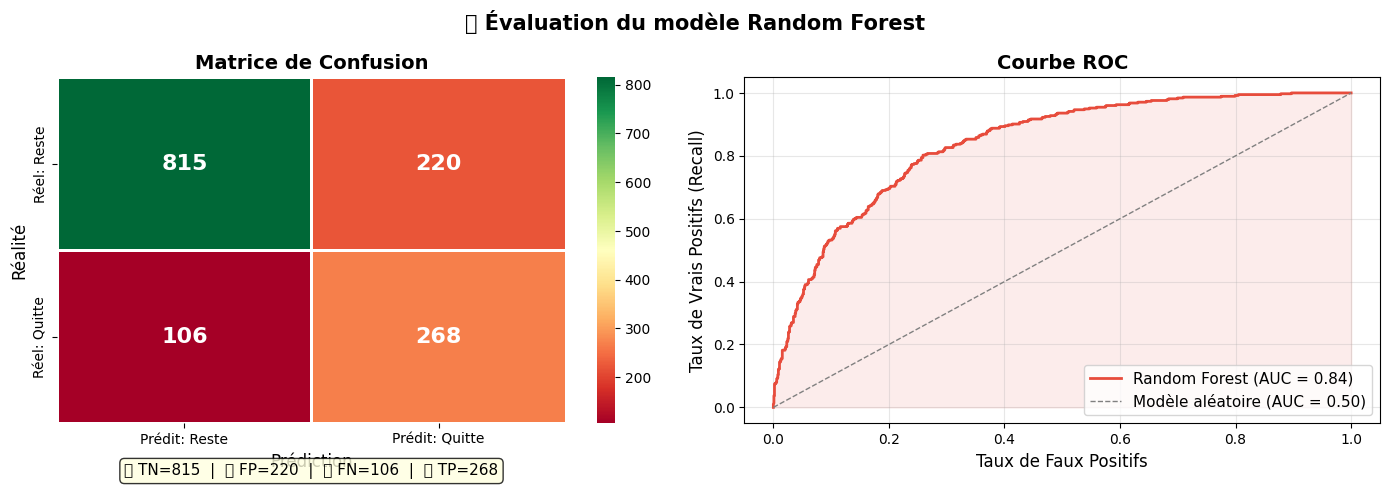


💡 Interprétation ROC-AUC :
   0.50 = modèle aléatoire (inutile)
   0.70 = acceptable
   0.80 = bon
   0.90 = excellent
   Notre modèle : 0.84 → Bon ✅


In [11]:
# ================================
# ÉVALUATION — Étape 2
# Matrice de confusion
# ================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Matrice de confusion ---
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Prédit: Reste', 'Prédit: Quitte'],
            yticklabels=['Réel: Reste', 'Réel: Quitte'],
            ax=axes[0], linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})

axes[0].set_title('Matrice de Confusion', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Réalité', fontsize=12)
axes[0].set_xlabel('Prédiction', fontsize=12)

# Annotations explicatives
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15,
    f'✅ TN={tn}  |  ❌ FP={fp}  |  ❌ FN={fn}  |  ✅ TP={tp}',
    transform=axes[0].transAxes, ha='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- Graphique 2 : Courbe ROC ---
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'Random Forest (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1,
             linestyle='--', label='Modèle aléatoire (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Taux de Faux Positifs', fontsize=12)
axes[1].set_ylabel('Taux de Vrais Positifs (Recall)', fontsize=12)
axes[1].set_title('Courbe ROC', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 Évaluation du modèle Random Forest',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_modele.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Interprétation ROC-AUC :")
print(f"   0.50 = modèle aléatoire (inutile)")
print(f"   0.70 = acceptable")
print(f"   0.80 = bon")
print(f"   0.90 = excellent")
print(f"   Notre modèle : {roc_auc:.2f} → ", end="")
if roc_auc >= 0.90:
    print("Excellent ✅")
elif roc_auc >= 0.80:
    print("Bon ✅")
elif roc_auc >= 0.70:
    print("Acceptable ⚠️")
else:
    print("À améliorer ❌")

####3. Importance des variables

/tmp/ipykernel_448/3080635369.py:33: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_448/3080635369.py:34: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


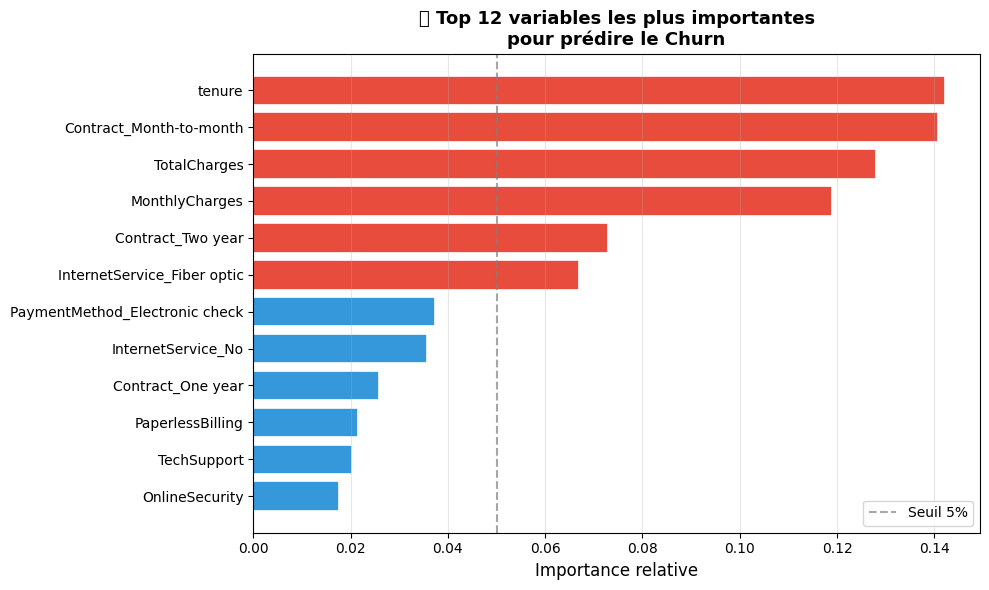


🔑 Top 5 variables décisives :
   1. tenure                         14.2%
   2. Contract_Month-to-month        14.1%
   3. TotalCharges                   12.8%
   4. MonthlyCharges                 11.9%
   5. Contract_Two year              7.3%


In [12]:
# ================================
# ÉVALUATION — Étape 3
# Quelles variables influencent le plus ?
# ================================

feature_names = df.drop(columns=['Churn']).columns.tolist()
importances   = model.feature_importances_

# Trier par importance décroissante
indices = np.argsort(importances)[::-1]
top_n   = 12

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if importances[indices[i]] > 0.05
          else '#3498db'
          for i in range(top_n)]

bars = ax.barh(
    [feature_names[i] for i in indices[:top_n]][::-1],
    [importances[indices[i]] for i in range(top_n)][::-1],
    color=colors[::-1], edgecolor='white', linewidth=1.2
)

ax.set_xlabel("Importance relative", fontsize=12)
ax.set_title("🔑 Top 12 variables les plus importantes\npour prédire le Churn",
             fontsize=13, fontweight='bold')
ax.axvline(x=0.05, color='gray', linestyle='--',
           alpha=0.7, label='Seuil 5%')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 Top 5 variables décisives :")
for i in range(5):
    idx = indices[i]
    print(f"   {i+1}. {feature_names[idx]:<30} {importances[idx]*100:.1f}%")

###Sauvegarder le modèle

In [13]:
# ================================
# SAUVEGARDE DU MODÈLE
# ================================

import joblib

# Sauvegarder le modèle entraîné
joblib.dump(model, 'random_forest_churn.pkl')
joblib.dump(scaler, 'scaler_churn.pkl')

print("✅ Modèle sauvegardé : random_forest_churn.pkl")
print("✅ Scaler sauvegardé : scaler_churn.pkl")
print("\n💡 Ces fichiers permettent de recharger le modèle")
print("   sans avoir à le réentraîner.")

# Test de rechargement
model_charge = joblib.load('random_forest_churn.pkl')
print("\n✅ Test rechargement : OK")

✅ Modèle sauvegardé : random_forest_churn.pkl
✅ Scaler sauvegardé : scaler_churn.pkl

💡 Ces fichiers permettent de recharger le modèle
   sans avoir à le réentraîner.

✅ Test rechargement : OK


###Simulation d'un vrai client

In [14]:
# ================================
# SIMULATION — Prédire un nouveau client
# ================================

import pandas as pd
import numpy as np

# Profil d'un client fictif à risque
nouveau_client = pd.DataFrame({
    'gender'                              : [1],
    'SeniorCitizen'                       : [0],
    'Partner'                             : [0],
    'Dependents'                          : [0],
    'tenure'                              : [2],
    'PhoneService'                        : [1],
    'MultipleLines'                       : [0],
    'OnlineSecurity'                      : [0],
    'OnlineBackup'                        : [0],
    'DeviceProtection'                    : [0],
    'TechSupport'                         : [0],
    'StreamingTV'                         : [1],
    'StreamingMovies'                     : [1],
    'PaperlessBilling'                    : [1],
    'MonthlyCharges'                      : [85.0],
    'TotalCharges'                        : [170.0],
    'InternetService_DSL'                 : [0],
    'InternetService_Fiber optic'         : [1],
    'InternetService_No'                  : [0],
    'Contract_Month-to-month'             : [1],
    'Contract_One year'                   : [0],
    'Contract_Two year'                   : [0],
    'PaymentMethod_Bank transfer (automatic)' : [0],
    'PaymentMethod_Credit card (automatic)'   : [0],
    'PaymentMethod_Electronic check'          : [1],
    'PaymentMethod_Mailed check'              : [0]
})

# Normaliser avec le même scaler
client_normalise = scaler.transform(nouveau_client)

# Prédiction
prediction   = model.predict(client_normalise)[0]
probabilite  = model.predict_proba(client_normalise)[0][1]

print("=" * 50)
print("👤 PROFIL DU CLIENT")
print("=" * 50)
print("   Homme, 2 mois d'ancienneté")
print("   Contrat : Month-to-month")
print("   Internet : Fiber optic")
print("   Facture mensuelle : 85$/mois")
print("   Paiement : Electronic check")
print("   Aucun service support/sécurité")

print("\n" + "=" * 50)
print("🤖 PRÉDICTION DU MODÈLE")
print("=" * 50)

if prediction == 1:
    print(f"   ⚠️  CE CLIENT VA PROBABLEMENT PARTIR")
    print(f"   📊 Probabilité de churn : {probabilite*100:.1f}%")
    print(f"   💡 Action recommandée   : Contacter immédiatement")
    print(f"                            Proposer une offre de rétention")
else:
    print(f"   ✅ CE CLIENT VA PROBABLEMENT RESTER")
    print(f"   📊 Probabilité de churn : {probabilite*100:.1f}%")

👤 PROFIL DU CLIENT
   Homme, 2 mois d'ancienneté
   Contrat : Month-to-month
   Internet : Fiber optic
   Facture mensuelle : 85$/mois
   Paiement : Electronic check
   Aucun service support/sécurité

🤖 PRÉDICTION DU MODÈLE
   ⚠️  CE CLIENT VA PROBABLEMENT PARTIR
   📊 Probabilité de churn : 88.3%
   💡 Action recommandée   : Contacter immédiatement
                            Proposer une offre de rétention


##GitHub

In [24]:
# ================================
# TÉLÉCHARGEMENT DES FICHIERS
# ================================

from google.colab import files

# Télécharger le notebook
# (Fichier → Télécharger → .ipynb dans le menu Colab)

# Télécharger les images et le modèle
files.download('churn_distribution.png')
files.download('numeric_features.png')
files.download('categorical_features.png')
files.download('evaluation_modele.png')
files.download('feature_importance.png')
files.download('random_forest_churn.pkl')
files.download('scaler_churn.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>